In [55]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ranjitmandal/fraud-detection-dataset-csv")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\V I C T U S\.cache\kagglehub\datasets\ranjitmandal\fraud-detection-dataset-csv\versions\1


In [57]:
# See what files are in the folder
print(os.listdir(path))

# Load the CSV (replace filename with whatever shows up above)
df = pd.read_csv(os.path.join(path, 'Fraud Detection Dataset.csv'))
print(df.head())

['Fraud Detection Dataset.csv']
  Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
0             T1     4174             1292.76   ATM Withdrawal   
1             T2     4507             1554.58   ATM Withdrawal   
2             T3     1860             2395.02   ATM Withdrawal   
3             T4     2294              100.10     Bill Payment   
4             T5     2130             1490.50      POS Payment   

   Time_of_Transaction Device_Used       Location  \
0                 16.0      Tablet  San Francisco   
1                 13.0      Mobile       New York   
2                  NaN      Mobile            NaN   
3                 15.0     Desktop        Chicago   
4                 19.0      Mobile  San Francisco   

   Previous_Fraudulent_Transactions  Account_Age  \
0                                 0          119   
1                                 4           79   
2                                 3          115   
3                                 4         

In [58]:
# How many rows and columns?
print("Shape of data:", df.shape)

Shape of data: (51000, 12)


In [59]:
# What are the column names?
print("\nColumn Names:", df.columns.tolist())


Column Names: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


In [87]:
# Are there any missing values?
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
hour                                0
day                                 0
dtype: int64


In [86]:
df['Transaction_Amount'].fillna(df['Transaction_Amount'].median(), inplace=True)
cols = ['Device_Used', 'Location', 'Payment_Method']

for col in cols:
    df[col].fillna('Unknown', inplace=True)
df['Time_of_Transaction'] = pd.to_datetime(df['Time_of_Transaction'], errors='coerce')

# Extract useful features
df['hour'] = df['Time_of_Transaction'].dt.hour
df['day'] = df['Time_of_Transaction'].dt.day

# Fill missing extracted values
df['hour'].fillna(df['hour'].median(), inplace=True)
df['day'].fillna(df['day'].median(), inplace=True)

# Drop original column
df.drop('Time_of_Transaction', axis=1, inplace=True)


C:\Users\V I C T U S\AppData\Local\Temp\ipykernel_10640\3940958081.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Transaction_Amount'].fillna(df['Transaction_Amount'].median(), inplace=True)
C:\Users\V I C T U S\AppData\Local\Temp\ipykernel_10640\3940958081.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

In [88]:
data = df.copy()
target_col = 'Fraudulent'

In [89]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    data[col] = data[col].fillna(data[col].mean())

In [90]:
cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [91]:
# Data types of each column
print("\nData Types:")
print(df.dtypes)


Data Types:
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
hour                                float64
day                                 float64
dtype: object


Class Distribution:
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


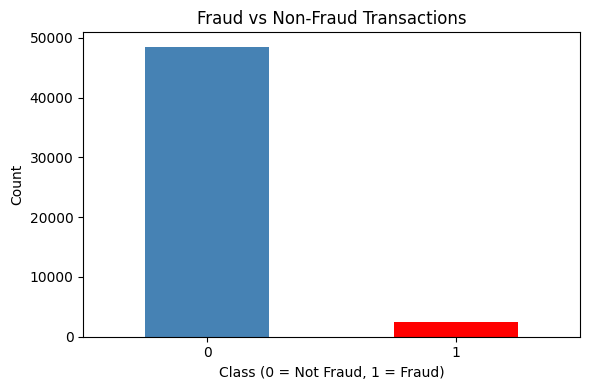


Fraud cases: 2510 (4.92%)
Non-Fraud cases: 48490 (95.08%)


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check how many fraud vs non-fraud cases we have
# (Assuming the target column is called 'isFraud' - change if different)
target_col = 'Fraudulent'   # <-- Change this to match your actual column name

print("Class Distribution:")
print(df[target_col].value_counts())

# Plot it
plt.figure(figsize=(6, 4))
df[target_col].value_counts().plot(kind='bar', color=['steelblue', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class (0 = Not Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Show percentage
total = len(df)
fraud_count = df[target_col].sum()
print(f"\nFraud cases: {fraud_count} ({fraud_count/total*100:.2f}%)")
print(f"Non-Fraud cases: {total - fraud_count} ({(total-fraud_count)/total*100:.2f}%)")

In [93]:
from sklearn.preprocessing import LabelEncoder

# Make a copy so we don't mess up original data
data = df.copy()

# Drop columns that are not useful for prediction (like ID or name columns)
# Check your column names and remove any that are just IDs or text
# Example: data = data.drop(['nameOrig', 'nameDest'], axis=1)

# Convert any text/category columns to numbers using LabelEncoder
for col in data.select_dtypes(include='object').columns:
    if col != target_col:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        print(f"Encoded column: {col}")

# Separate features (X) and target (y)
X = data.drop(target_col, axis=1)
y = data[target_col]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Encoded column: Transaction_ID
Encoded column: Transaction_Type
Encoded column: Device_Used
Encoded column: Location
Encoded column: Payment_Method

Features shape: (51000, 12)
Target shape: (51000,)


In [95]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    if col != target_col:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))

In [104]:
X = data.drop(target_col, axis=1)
y = data[target_col]

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [107]:
# Logistic Regression (scaled)
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Random Forest (no scaling)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [108]:
# Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [111]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
print("F1 Score - Logistic Regression:", f1_score(y_test, y_pred_lr))
print("F1 Score - Random Forest:", f1_score(y_test, y_pred_rf))

print("ROC-AUC - Logistic Regression:", roc_auc_score(y_test, y_prob_lr))
print("ROC-AUC - Random Forest:", roc_auc_score(y_test, y_prob_rf))

F1 Score - Logistic Regression: 0.09015639374425023
F1 Score - Random Forest: 0.08598130841121496
ROC-AUC - Logistic Regression: 0.5051402588898638
ROC-AUC - Random Forest: 0.53781347172404


We implemented a machine learning-based fraud detection system and proposed prevention strategies including real-time monitoring, risk-based authentication, behavioral analysis, and continuous model retraining to minimize fraud and improve security.

1. Real time transaction monitoring
2. Multi factor authentication
3. Risk-based threshold system

